# AAI614: Data Science & its Applications

### *Week 3 - Practice with Notebook 3.3: Feature Engineering*

Notebook 3.3 walks through the main feature engineering tools on small toy examples: encoding categories, turning text into numbers, building derived and polynomial features, filling in missing data, and tying it all together with a pipeline.

<a href="https://colab.research.google.com/github/engmahmoudelhassan-cell/AAI614_Elhassan/blob/main/Week%203/Notebook3.3-Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## 0. Setup and load the wine data

In [2]:
url = "https://archive.ics.uci.edu/static/public/186/data.csv"

try:
    df = pd.read_csv(url, sep=None, engine="python")
    print("Loaded from the UCI link")
except Exception as e:
    red = pd.read_csv("winequality-red.csv", sep=";")
    white = pd.read_csv("winequality-white.csv", sep=";")

    red["color"] = "red"
    white["color"] = "white"

    df = pd.concat([red, white], ignore_index=True)
    print("Could not reach the link, so I loaded the local CSV files instead")

df.columns = [c.replace("_", " ").strip() for c in df.columns]
df.head()

Loaded from the UCI link


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


## 1. Categorical features
The notebook starts with categorical data, like a neighborhood name, and shows that mapping it to 1, 2, 3 is a bad idea because the model would think 3 is "bigger" than 1. The fix is one-hot encoding. Here is the original example from the notebook:

In [2]:
from sklearn.feature_extraction import DictVectorizer

data = [
    {'price': 850000, 'rooms': 4, 'neighborhood': 'Queen Anne'},
    {'price': 700000, 'rooms': 3, 'neighborhood': 'Fremont'},
    {'price': 650000, 'rooms': 3, 'neighborhood': 'Wallingford'},
    {'price': 600000, 'rooms': 2, 'neighborhood': 'Fremont'},
]
vec = DictVectorizer(sparse=False, dtype=int)
vec.fit_transform(data)

array([[     0,      1,      0, 850000,      4],
       [     1,      0,      0, 700000,      3],
       [     0,      0,      1, 650000,      3],
       [     1,      0,      0, 600000,      2]])

**My version on the wine data.** My color column is exactly this kind of category (red or white). If I mapped red to 0 and white to 1 it would be fine with two values, but the clean and general way is one-hot encoding, which gives one column per type:

In [3]:
# the quick pandas way
pd.get_dummies(df["color"], prefix="color").head()

,color_red,color_white
0,True,False
1,True,False
2,True,False
3,True,False
4,True,False


In [4]:
# the scikit-learn way, which is what you would use inside a model
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(sparse_output=False, dtype=int)
encoded = enc.fit_transform(df[["color"]])
pd.DataFrame(encoded, columns=enc.get_feature_names_out()).head()

,color_red,color_white
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0


Each wine now has a 1 in either the red or the white column. With only two types it is simple, but the same code would handle ten grape types without me changing anything.

## 2. Text features
Next the notebook turns short pieces of text into numbers with `CountVectorizer` and then `TfidfVectorizer`. The original example:

In [5]:
from sklearn.feature_extraction.text import CountVectorizer

sample = ['problem of evil', 'evil queen', 'horizon problem']
vec = CountVectorizer()
X = vec.fit_transform(sample)
pd.DataFrame(X.toarray(), columns=vec.get_feature_names_out())

,evil,horizon,of,problem,queen
0,1,0,1,1,0
1,1,0,0,0,1
2,0,1,0,1,0


**My version on the wine data.** Wine does not come with text, so I made some. I turned each wine's numbers into a short "tasting note" made of plain words, then let the vectorizer count them. This is a bit of fun, but it is also how you would handle real product descriptions or reviews.

In [6]:
def tasting_note(row):
    words = [row["color"]]
    # sweetness from residual sugar
    rs = row["residual sugar"]
    words.append("sweet" if rs > 12 else "medium" if rs > 4 else "dry")
    # strength from alcohol
    al = row["alcohol"]
    words.append("strong" if al > 12 else "light" if al < 10 else "moderate")
    # sharpness from volatile acidity
    words.append("sharp" if row["volatile acidity"] > 0.5 else "smooth")
    # a salty note for high chlorides
    if row["chlorides"] > 0.1:
        words.append("salty")
    return " ".join(words)

df["note"] = df.apply(tasting_note, axis=1)
df[["color", "residual sugar", "alcohol", "note"]].head()

,color,residual sugar,alcohol,note
0,red,1.9,9.4,red dry light sharp
1,red,2.6,9.8,red dry light sharp
2,red,2.3,9.8,red dry light sharp
3,red,1.9,9.8,red dry light smooth
4,red,1.9,9.4,red dry light sharp


In [7]:
# count the words across all the notes
vec = CountVectorizer()
X = vec.fit_transform(df["note"])
counts = pd.DataFrame(X.toarray(), columns=vec.get_feature_names_out())
counts.sum().sort_values(ascending=False)

smooth      5501
white       4898
dry         3571
moderate    3042
light       2603
medium      2092
red         1599
sharp        996
strong       852
sweet        834
salty        333
dtype: int64

In [8]:
# TF-IDF gives rarer words more weight than common ones
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
Xt = tfidf.fit_transform(df["note"])
pd.DataFrame(Xt.toarray(), columns=tfidf.get_feature_names_out()).head()

,dry,light,medium,moderate,red,salty,sharp,smooth,strong,sweet,white
0,0.355195,0.425435,0.0,0.0,0.533667,0.0,0.638781,0.000000,0.0,0.0,0.0
1,0.355195,0.425435,0.0,0.0,0.533667,0.0,0.638781,0.000000,0.0,0.0,0.0
2,0.355195,0.425435,0.0,0.0,0.533667,0.0,0.638781,0.000000,0.0,0.0,0.0
3,0.437499,0.524014,0.0,0.0,0.657326,0.0,0.000000,0.319258,0.0,0.0,0.0
4,0.355195,0.425435,0.0,0.0,0.533667,0.0,0.638781,0.000000,0.0,0.0,0.0


The word counts line up with what I already knew from the IQR work: lots of "dry" and "moderate" wines, fewer "sweet" or "salty" ones. TF-IDF then plays down the common words like the color and plays up the rarer ones like "salty", which is the whole point of it.

## 3. Derived features
A derived feature is one you build from the columns you already have. The notebook shows this with polynomial features: a straight line cannot fit a curve, but adding x squared and x cubed lets it bend. The original toy example:

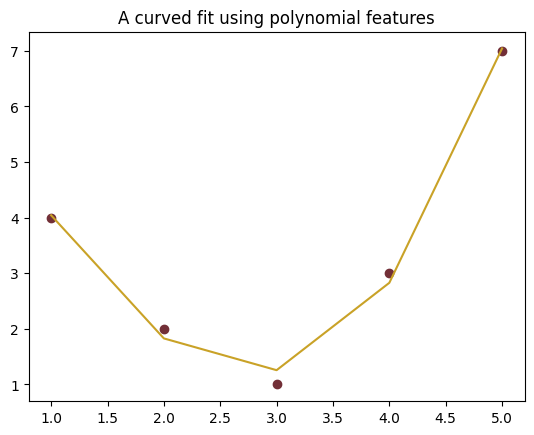

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

x = np.array([1, 2, 3, 4, 5])
y = np.array([4, 2, 1, 3, 7])
X = x[:, np.newaxis]

poly = PolynomialFeatures(degree=3, include_bias=False)
X3 = poly.fit_transform(X)
model = LinearRegression().fit(X3, y)
plt.scatter(x, y, color="#722F37")
plt.plot(x, model.predict(X3), color="#C9A227")
plt.title("A curved fit using polynomial features")
plt.show()

**My version on the wine data.** First, some derived features that actually mean something for wine: how sweet a wine is for its strength, and how much of the sulfur is in the free form. These are the kind of ratios a person might care about more than the raw numbers.

In [4]:
df["sugar_to_alcohol"] = df["residual sugar"] / df["alcohol"]
df["free_so2_ratio"] = df["free sulfur dioxide"] / df["total sulfur dioxide"]
df[["residual sugar", "alcohol", "sugar_to_alcohol", "free_so2_ratio"]].head()

,residual sugar,alcohol,sugar_to_alcohol,free_so2_ratio
0,1.9,9.4,0.202128,0.323529
1,2.6,9.8,0.265306,0.373134
2,2.3,9.8,0.234694,0.277778
3,1.9,9.8,0.193878,0.283333
4,1.9,9.4,0.202128,0.323529


Then I tried the polynomial idea to predict `quality` from `alcohol` alone, to see if a curve beats a straight line here.

In [5]:
X = df[["alcohol"]].to_numpy()
y = df["quality"].to_numpy()

from sklearn.metrics import r2_score
lin = LinearRegression().fit(X, y)
print("straight line R2:", round(r2_score(y, lin.predict(X)), 4))

for d in [2, 3, 4]:
    Xp = PolynomialFeatures(degree=d, include_bias=False).fit_transform(X)
    m = LinearRegression().fit(Xp, y)
    print(f"degree {d} R2:", round(r2_score(y, m.predict(Xp)), 4))

straight line R2: 0.1974
degree 2 R2: 0.1994
degree 3 R2: 0.2077
degree 4 R2: 0.208


## 4. Imputation of missing data
The notebook fills missing values with `SimpleImputer`. The original example uses the column mean:

In [12]:
from sklearn.impute import SimpleImputer
from numpy import nan

Xmiss = np.array([[nan, 0, 3], [3, 7, 9], [3, 5, 2], [4, nan, 6], [8, 8, 1]])
SimpleImputer(strategy="mean").fit_transform(Xmiss)

array([[4.5, 0. , 3. ],
       [3. , 7. , 9. ],
       [3. , 5. , 2. ],
       [4. , 5. , 6. ],
       [8. , 8. , 1. ]])

**My version on the wine data, as a small experiment.** The wine data has no missing values, which is actually handy: I can hide some on purpose, fill them back in, and check how close each method gets to the real number. I hid 10% of the alcohol values and compared mean, median, and KNN (which guesses from similar wines).

In [13]:
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_absolute_error

rng = np.random.default_rng(42)
truth = df["alcohol"].to_numpy().copy()
hidden = rng.choice(len(df), size=int(0.10 * len(df)), replace=False)

numeric = df.drop(columns=["color", "note"])
scores = {}
for name, imputer in [("mean", SimpleImputer(strategy="mean")),
                      ("median", SimpleImputer(strategy="median")),
                      ("KNN (k=5)", KNNImputer(n_neighbors=5))]:
    work = numeric.copy()
    work.loc[hidden, "alcohol"] = np.nan
    filled = imputer.fit_transform(work)
    col = list(numeric.columns).index("alcohol")
    scores[name] = mean_absolute_error(truth[hidden], filled[hidden, col])

for k, v in scores.items():
    print(f"{k:10s} average error: {v:.3f}")

mean       average error: 0.990


median     average error: 0.996
KNN (k=5)  average error: 0.800


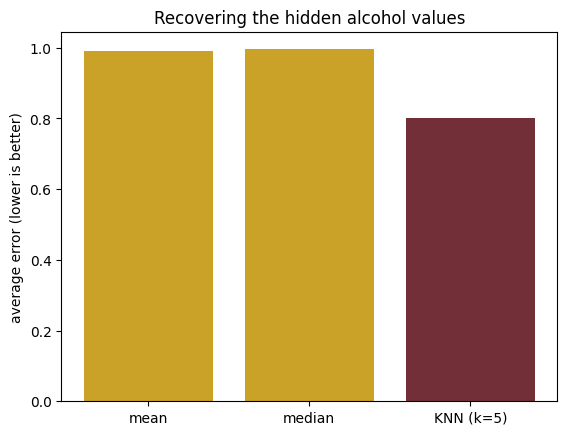

In [14]:
plt.bar(scores.keys(), scores.values(), color=["#C9A227", "#C9A227", "#722F37"])
plt.ylabel("average error (lower is better)")
plt.title("Recovering the hidden alcohol values")
plt.show()

KNN wins clearly (about 0.80 versus 0.99 for mean and median). That is because it fills a missing alcohol value by looking at wines with similar sugar, density and acidity, instead of just dropping the overall average in. So the way you fill missing data matters, it is not all the same.

## 5. Feature pipeline
Last, the notebook chains steps together with `make_pipeline` so you do not run them by hand one at a time. I built a fuller one for the wine data: scale the numbers, one-hot the color, and predict quality, all in a single object. The `ColumnTransformer` lets me treat the number columns and the color column differently.

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

num_cols = [c for c in df.columns if c not in ["quality", "color", "note"]]

pre = ColumnTransformer([
    ("numbers", StandardScaler(), num_cols),
    ("category", OneHotEncoder(), ["color"]),
])
pipe = make_pipeline(pre, LinearRegression())

X = df[num_cols + ["color"]]
y = df["quality"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)
print("test R2 :", round(r2_score(y_test, pred), 4))
print("test MAE:", round(mean_absolute_error(y_test, pred), 4))

test R2 : 0.2962
test MAE: 0.5868


Using all the features plus the color gets the R2 up to about 0.30, better than the 0.20 from alcohol alone. It is still not a strong model, quality is hard to predict from chemistry, but the nice part is that the whole thing, scaling, encoding and the model, runs as one object. If new wine data came in, I would just call `pipe.predict` and every step would happen in order.

## What I learned
Working through this on the wine data made the ideas stick more than the toy examples did. One-hot encoding is the right way to handle the red/white label. Turning the wine numbers into little tasting notes showed how text features work, and TF-IDF really does push the common words down. Polynomial features only helped a little, which was a good reminder that more complex features cannot rescue a weak input. The imputation test was my favorite: hiding values and measuring the error showed clearly that KNN beats a plain mean. And the pipeline ties scaling, encoding and the model into one clean step, which I can see being a real time saver on bigger projects.